# IBM Data Analyst Capstone Project
## Module 5 — Data Visualization

**Goal:** Create clear, well-labelled charts that answer the key business questions:  
- Which programming languages / databases are most in-demand?  
- How is developer salary distributed?  
- How do salary and education level relate?  
- Where do developers prefer to work?  
- Which platforms are developers using and want to use next year?

**Every chart is automatically saved as a PNG to the `images/` folder.**

In [1]:
# ── CELL 1: Import libraries ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import urllib.request
import os

In [2]:
# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (10, 5)})

# All saved images will go here
IMG_DIR = os.path.join("..", "images")
os.makedirs(IMG_DIR, exist_ok=True)

def save_fig(filename):
    """Save current figure to IMG_DIR and display it."""
    path = os.path.join(IMG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()

In [3]:
# ── CELL 2: Download and connect to the SQLite database ───────────────────────
# The visualization module uses a SQLite database version of the survey data
DB_URL  = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DA0321EN-SkillsNetwork/LargeData/m4_survey_data.sqlite"
)
DB_PATH = "m4_survey_data.sqlite"

# Only download if not already present
if not os.path.exists(DB_PATH):
    print("Downloading database...")
    urllib.request.urlretrieve(DB_URL, DB_PATH)
    print("Done.")
else:
    print("Database already exists locally.")

# Open a connection
conn = sqlite3.connect(DB_PATH)
print("Connected to SQLite database.")

Done.
Connected to SQLite database.


In [4]:
# ── CELL 3: Helper — run SQL and return a DataFrame ───────────────────────────
def query(sql):
    """Execute a SQL query against conn and return a pandas DataFrame."""
    return pd.read_sql_query(sql, conn)

Saved → ..\images\01_salary_histogram.png


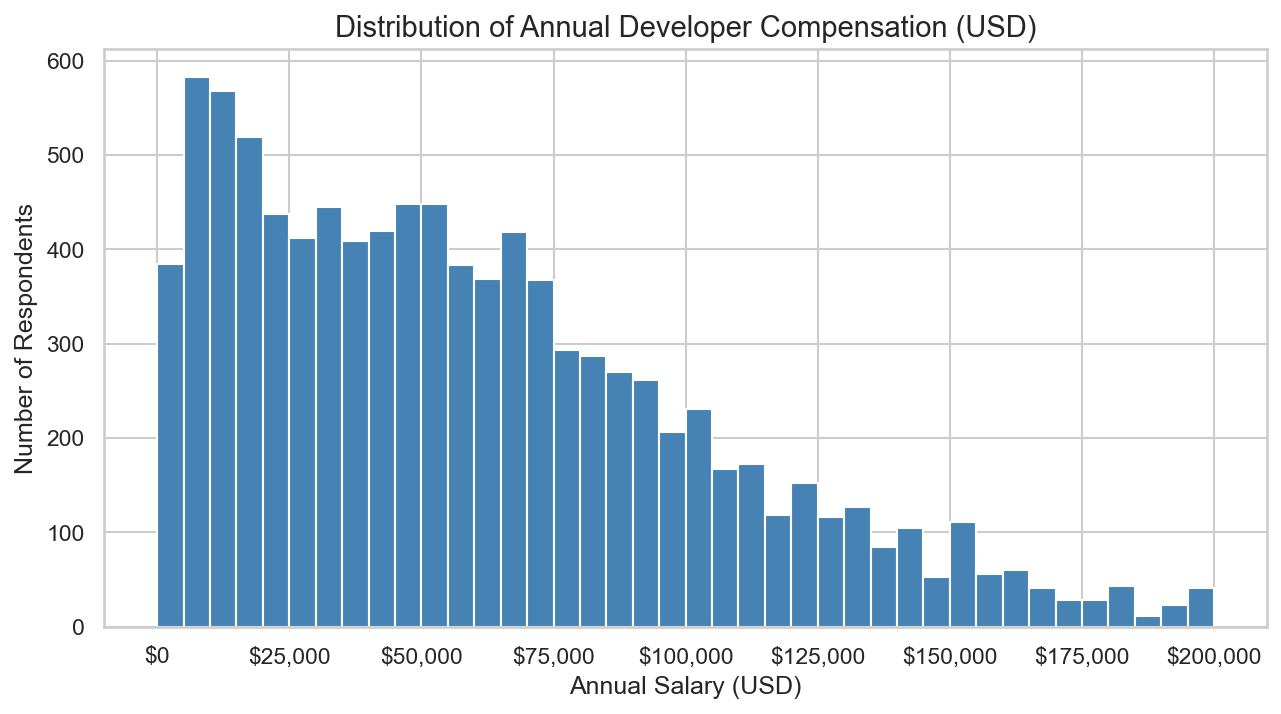

In [5]:
# ── CELL 4: CHART 1 — Histogram of annual compensation ───────────────────────
# Shows how developer salaries are distributed
df_comp = query("""
    SELECT ConvertedComp
    FROM   master
    WHERE  ConvertedComp IS NOT NULL
      AND  ConvertedComp <= 200000   -- cap at 200k to reduce extreme-outlier distortion
""")

fig, ax = plt.subplots()
ax.hist(df_comp["ConvertedComp"], bins=40, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Annual Developer Compensation (USD)", fontsize=14)
ax.set_xlabel("Annual Salary (USD)")
ax.set_ylabel("Number of Respondents")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
save_fig("01_salary_histogram.png")

Saved → ..\images\02_salary_by_education_boxplot.png


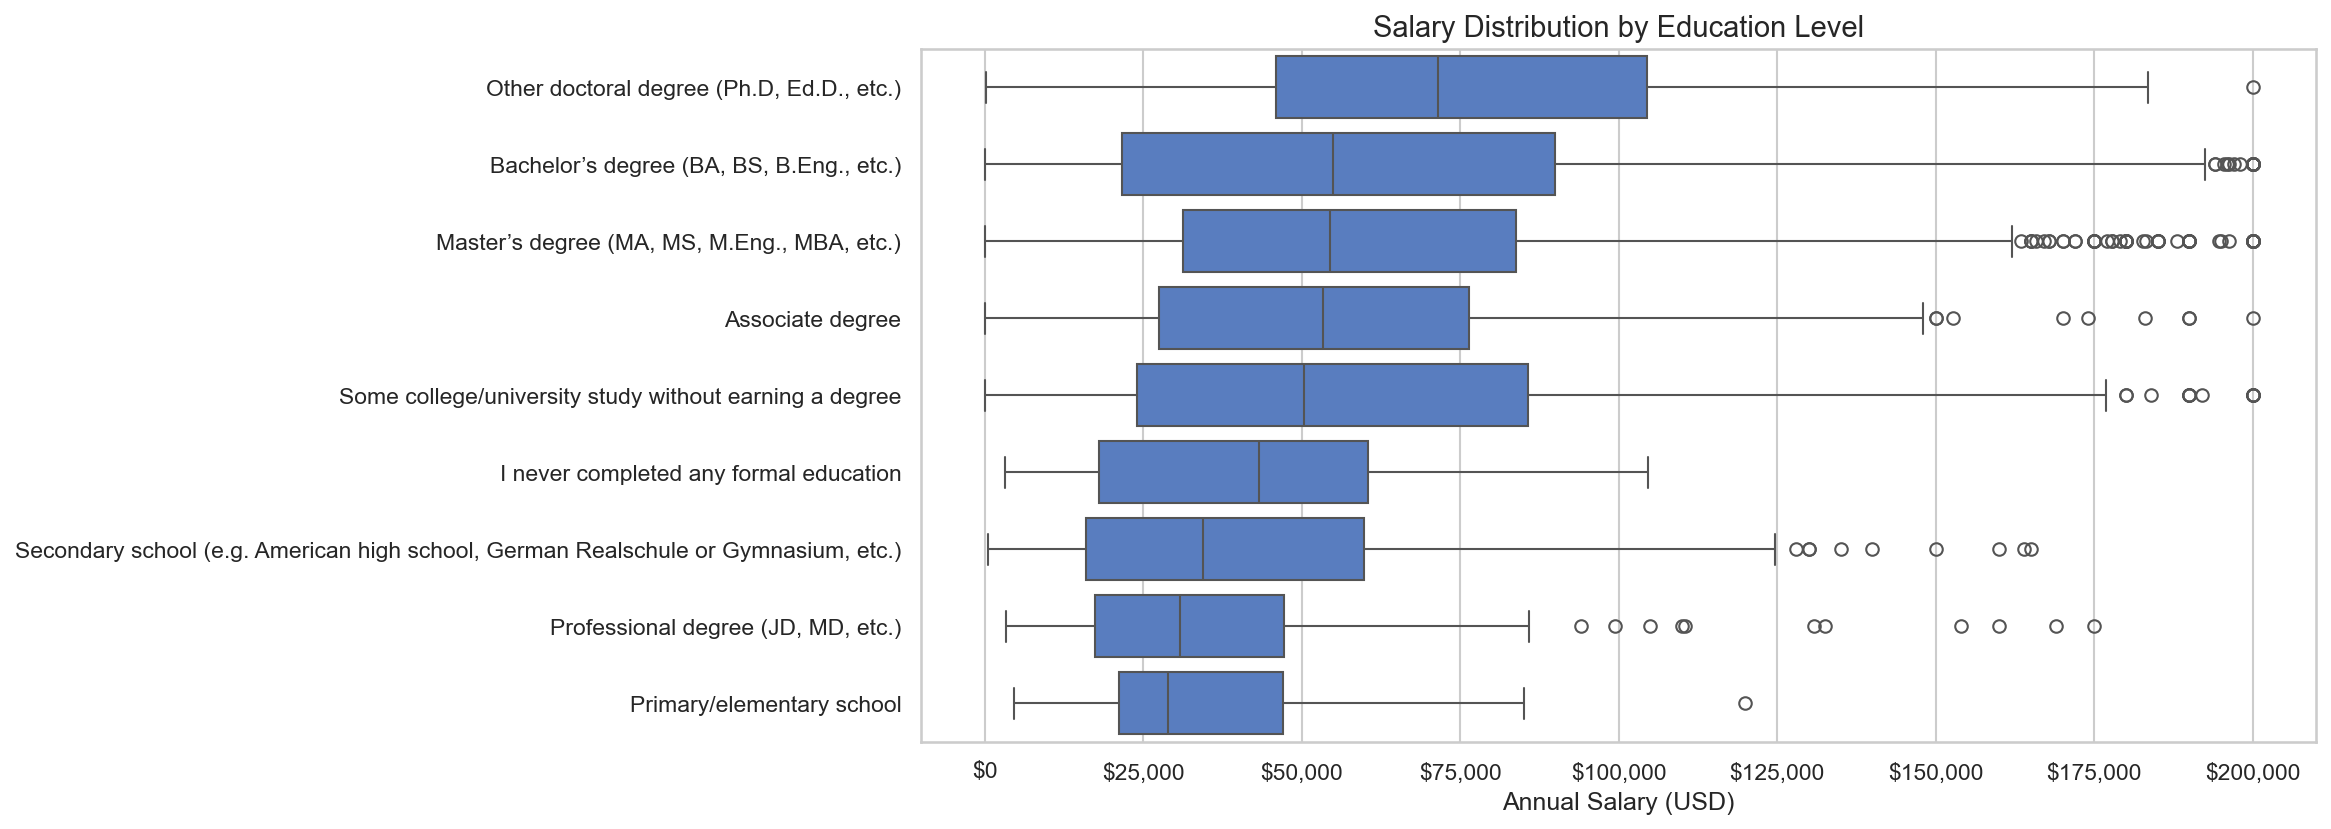

In [6]:
# ── CELL 5: CHART 2 — Box plot of salary by education level ──────────────────
# Reveals whether higher education correlates with higher pay
df_ed = query("""
    SELECT EdLevel, ConvertedComp
    FROM   master
    WHERE  EdLevel IS NOT NULL
      AND  ConvertedComp IS NOT NULL
      AND  ConvertedComp <= 200000
""")

# Sort categories by median salary for a more readable chart
order = (
    df_ed.groupby("EdLevel")["ConvertedComp"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_ed, x="ConvertedComp", y="EdLevel", order=order, ax=ax)
ax.set_title("Salary Distribution by Education Level", fontsize=14)
ax.set_xlabel("Annual Salary (USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
save_fig("02_salary_by_education_boxplot.png")

Saved → ..\images\03_top10_languages_worked_with.png


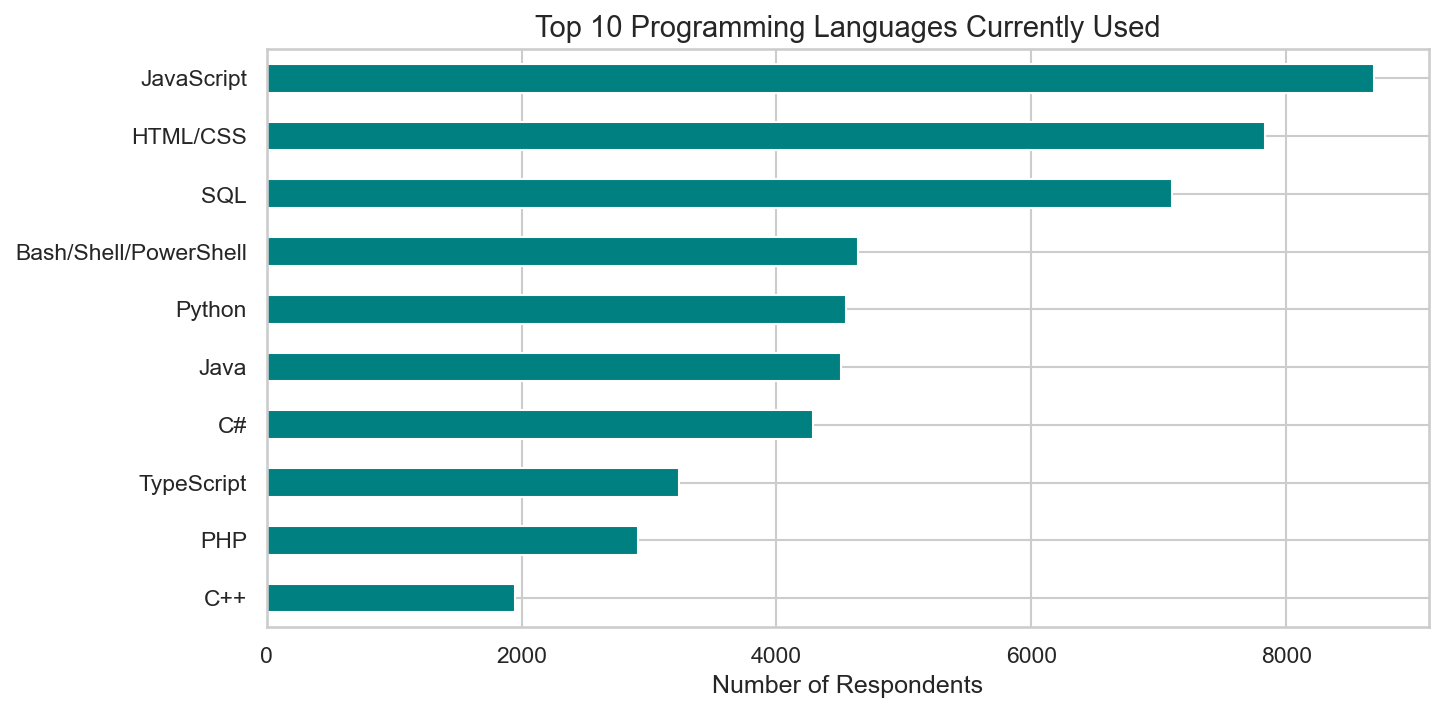

In [9]:
# ── CELL 6: CHART 3 — Bar chart: Top 10 languages worked with ────────────────
# This SQLite DB doesn't have LanguageWorkedWith — load from the IBM CSV instead
df_lang_csv = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv"
)

# Split semicolon-separated values, explode into one row per language, count
lang_series = (
    df_lang_csv["LanguageWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
lang_series.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 Programming Languages Currently Used", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("03_top10_languages_worked_with.png")

Saved → ..\images\04_top10_languages_desired.png


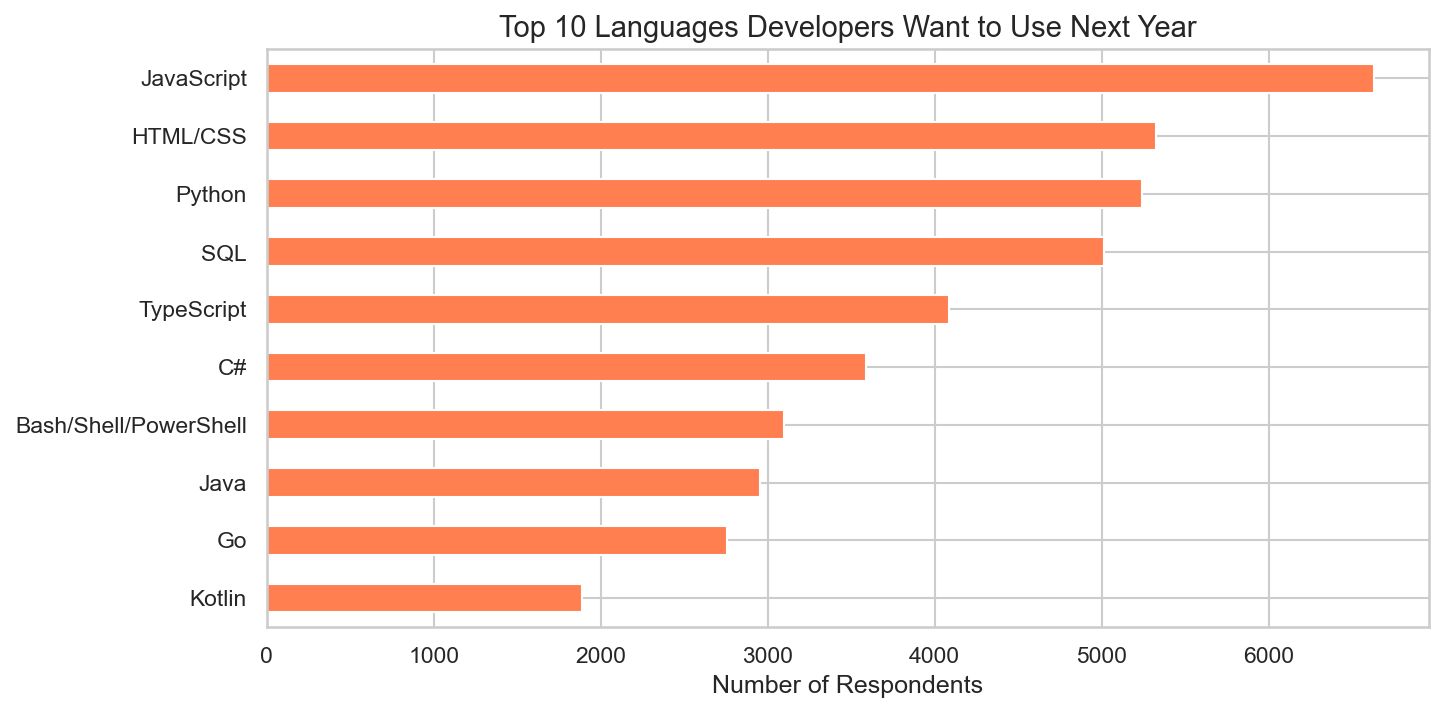

In [12]:
# ── CELL 7: CHART 4 — Bar chart: Top 10 languages desired next year ──────────
# LanguageDesireNextYear shows what developers want to learn / use next
df_lang_desire = df_lang_csv.copy() 

desire_series = (
    df_lang_desire["LanguageDesireNextYear"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
desire_series.sort_values().plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 10 Languages Developers Want to Use Next Year", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("04_top10_languages_desired.png")

Saved → ..\images\05_top10_databases_worked_with.png


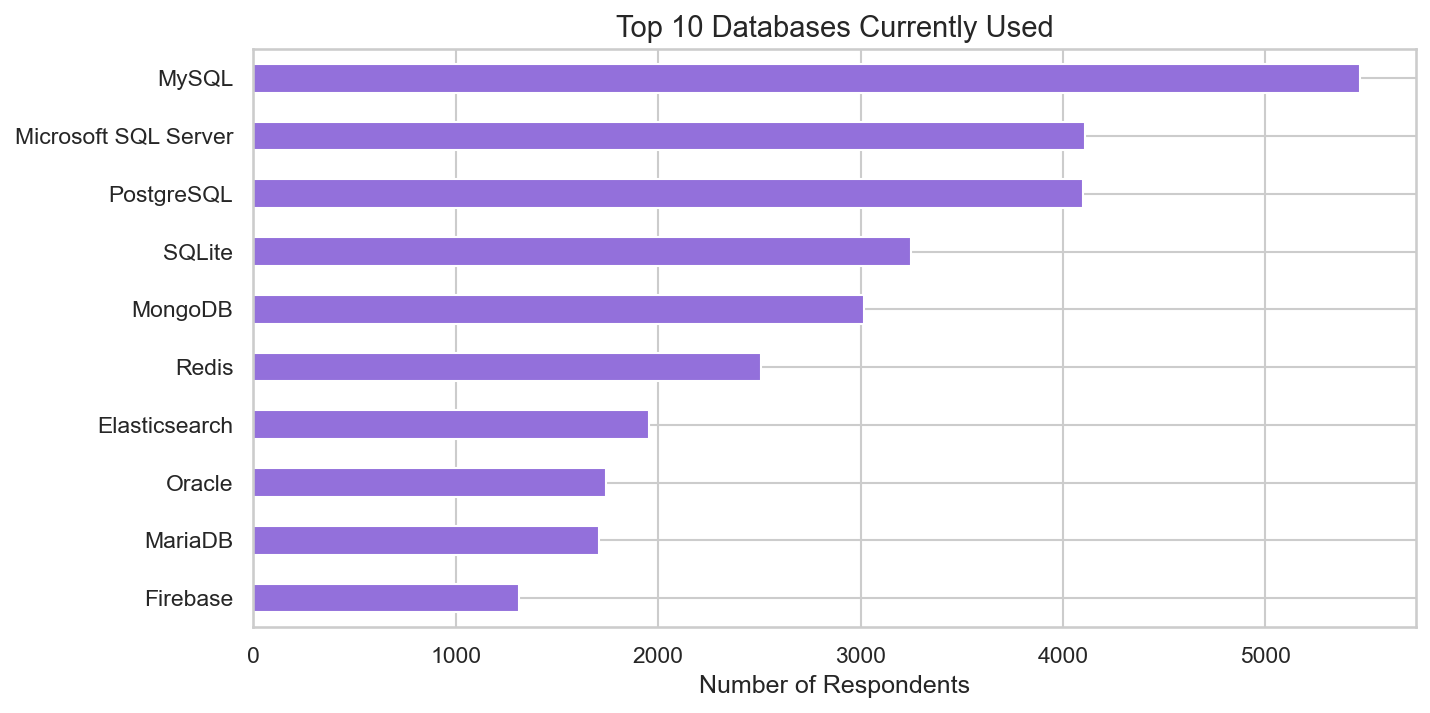

In [13]:
# ── CELL 8: CHART 5 — Bar chart: Top 10 databases currently used ─────────────
# CELL 8 — replace df_db_used query line with:
db_series = (
    df_lang_csv["DatabaseWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
db_series.sort_values().plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_title("Top 10 Databases Currently Used", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("05_top10_databases_worked_with.png")

Saved → ..\images\06_top10_databases_desired.png


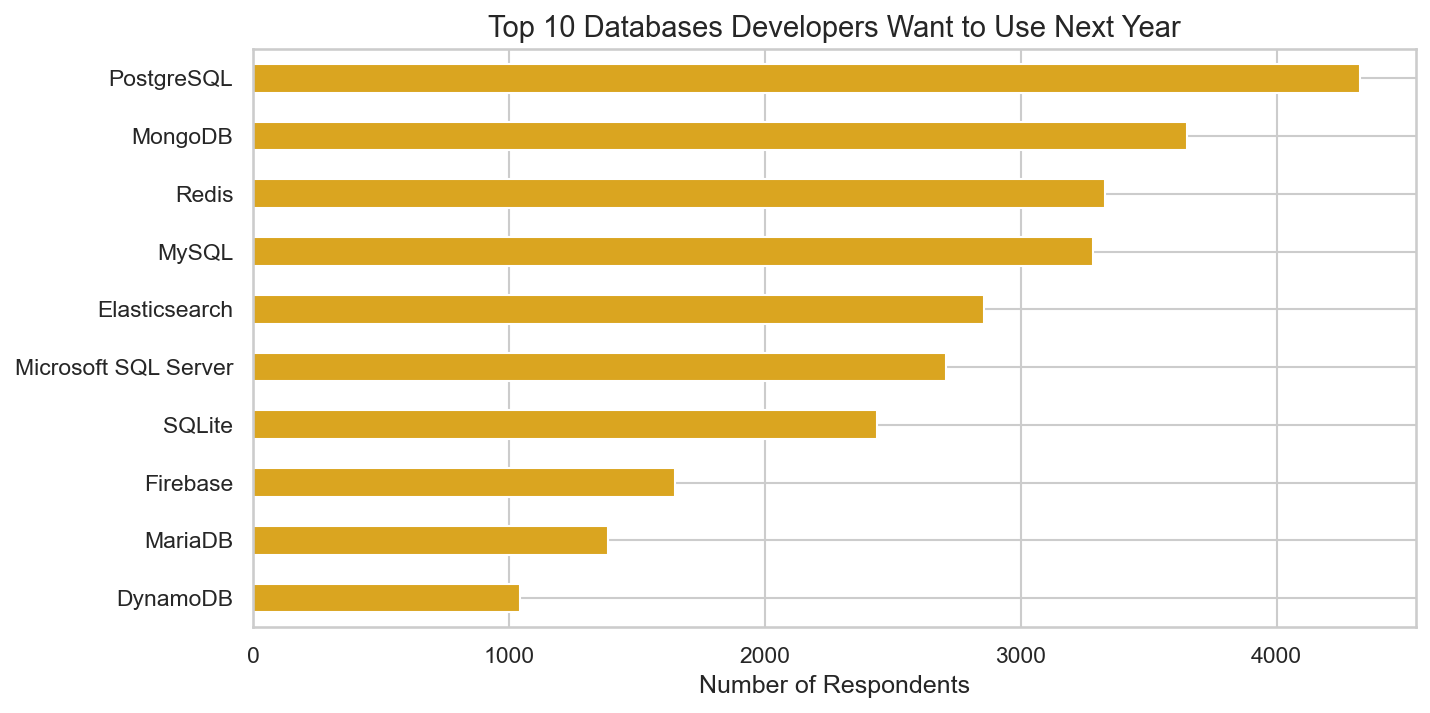

In [14]:
# ── CELL 9: CHART 6 — Bar chart: Top 10 databases desired next year ──────────
db_desire = (
    df_lang_csv["DatabaseDesireNextYear"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
db_desire.sort_values().plot(kind="barh", ax=ax, color="goldenrod")
ax.set_title("Top 10 Databases Developers Want to Use Next Year", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("06_top10_databases_desired.png")

Saved → ..\images\07_work_location_pie.png


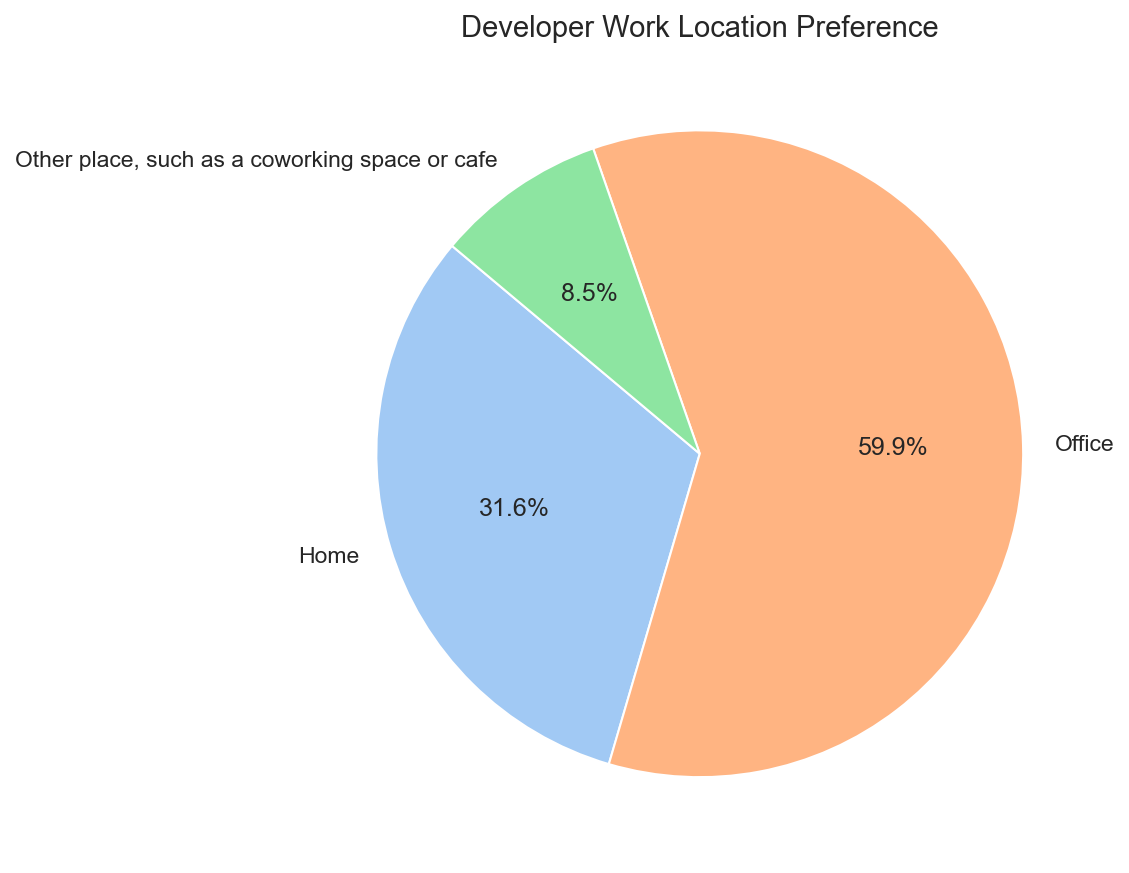

In [15]:
# ── CELL 10: CHART 7 — Pie chart: Work location preference ───────────────────
# Shows where most developers prefer to work (Home / Office / Other)
df_workloc = query(
    "SELECT WorkLoc, COUNT(*) AS Count FROM master WHERE WorkLoc IS NOT NULL GROUP BY WorkLoc"
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    df_workloc["Count"],
    labels=df_workloc["WorkLoc"],
    autopct="%1.1f%%",           # show percentage on each slice
    startangle=140,
    colors=sns.color_palette("pastel")
)
ax.set_title("Developer Work Location Preference", fontsize=14)
save_fig("07_work_location_pie.png")

Saved → ..\images\08_age_vs_salary_scatter.png


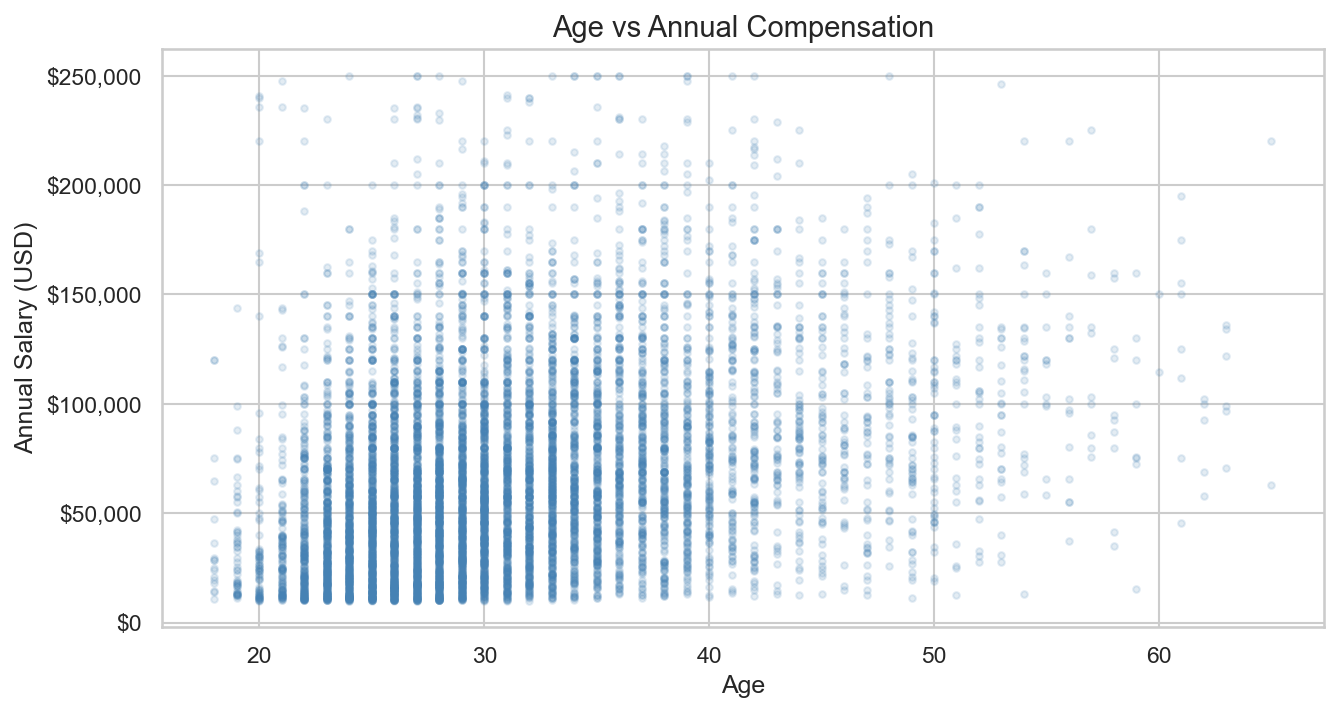

In [16]:
# ── CELL 11: CHART 8 — Scatter plot: Age vs Compensation ────────────────────
# Examines whether older developers earn more
df_age_sal = query("""
    SELECT Age, ConvertedComp
    FROM   master
    WHERE  Age IS NOT NULL
      AND  ConvertedComp IS NOT NULL
      AND  ConvertedComp BETWEEN 10000 AND 250000
      AND  Age BETWEEN 18 AND 65
""")

fig, ax = plt.subplots()
ax.scatter(
    df_age_sal["Age"], df_age_sal["ConvertedComp"],
    alpha=0.15, s=10, color="steelblue"   # low alpha handles overplotting
)
ax.set_title("Age vs Annual Compensation", fontsize=14)
ax.set_xlabel("Age")
ax.set_ylabel("Annual Salary (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
save_fig("08_age_vs_salary_scatter.png")

Saved → ..\images\09_top10_ides_used.png


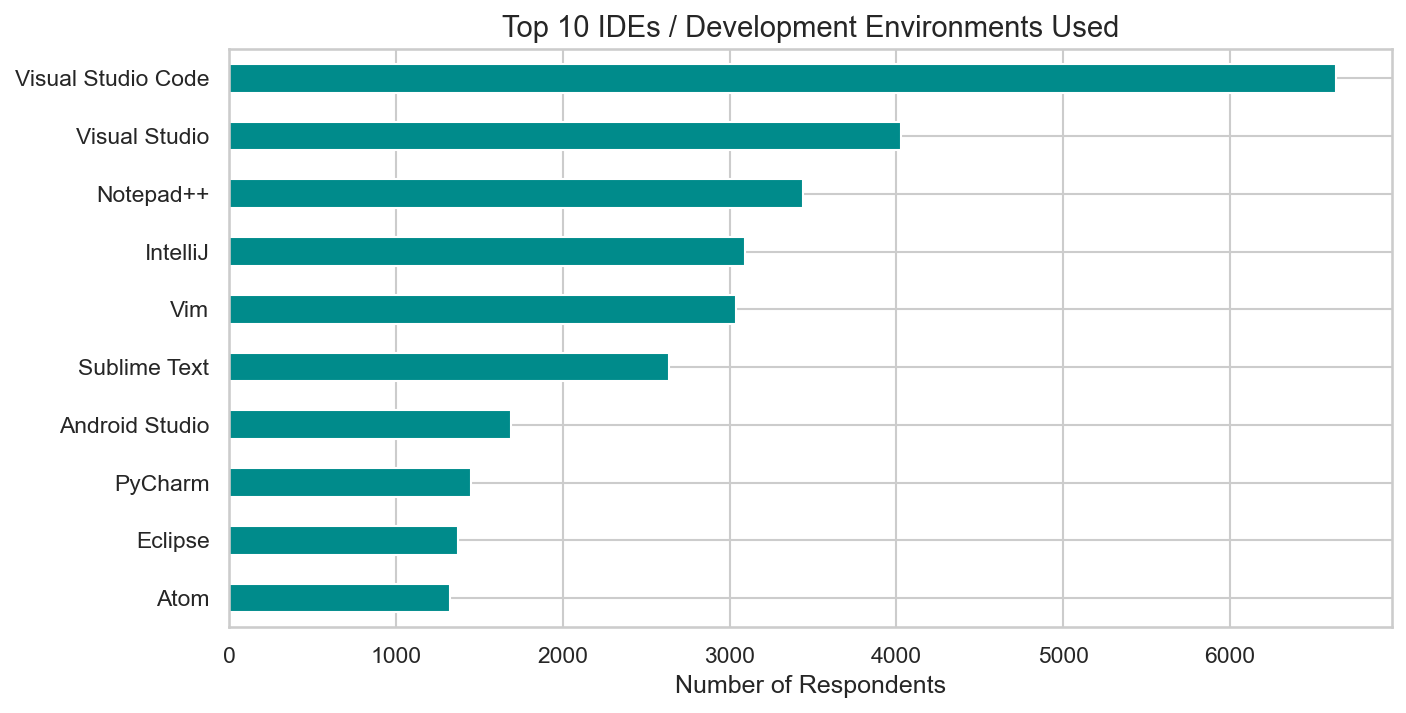

In [18]:
# ── CELL 12: CHART 9 — Bar chart: Top 10 IDEs currently used ─────────────────
# DevEnviron is a multi-value column — load from CSV (not in SQLite)
ide_series = (
    df_lang_csv["DevEnviron"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
ide_series.sort_values().plot(kind="barh", ax=ax, color="darkcyan")
ax.set_title("Top 10 IDEs / Development Environments Used", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("09_top10_ides_used.png")

Saved → ..\images\10_top10_countries.png


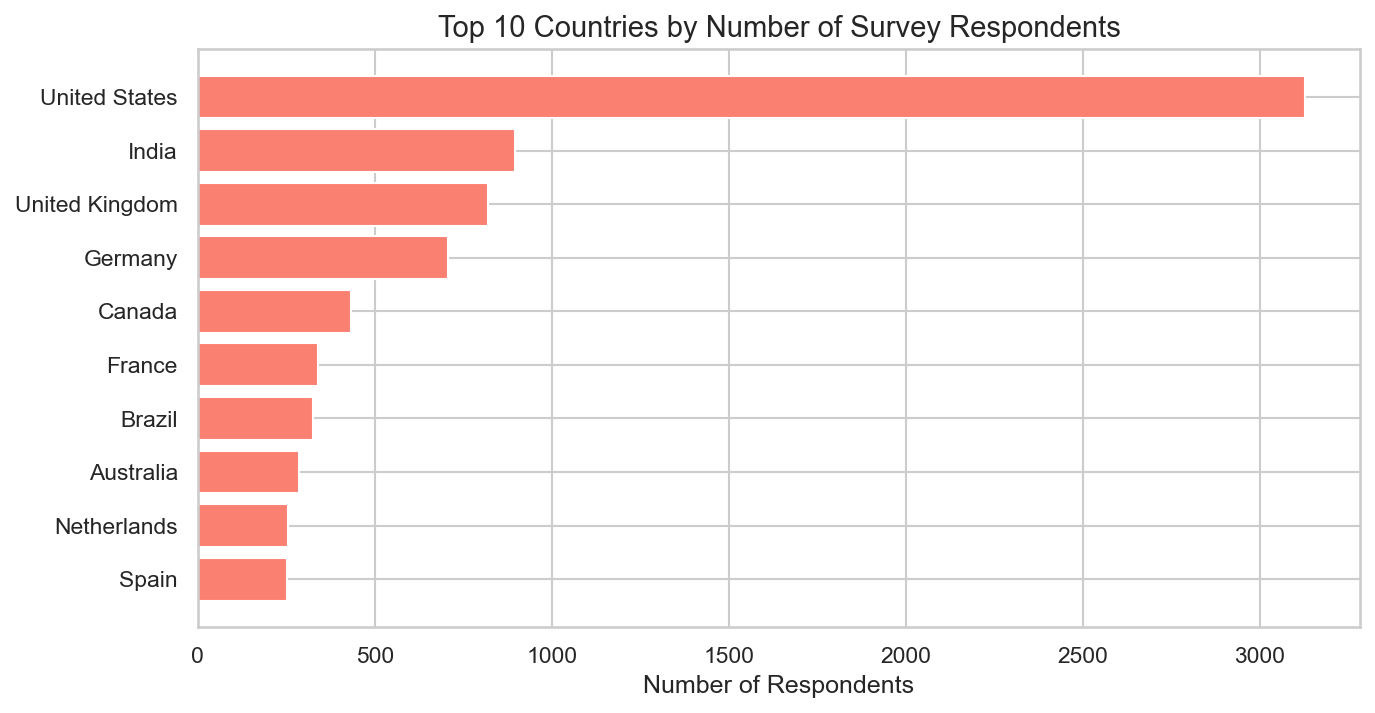

In [19]:
# ── CELL 13: CHART 10 — Bar chart: Respondent count by country (top 10) ──────
df_country = query("""
    SELECT Country, COUNT(*) AS Count
    FROM   master
    WHERE  Country IS NOT NULL
    GROUP  BY Country
    ORDER  BY Count DESC
    LIMIT  10
""")

fig, ax = plt.subplots()
ax.barh(df_country["Country"][::-1], df_country["Count"][::-1], color="salmon")
ax.set_title("Top 10 Countries by Number of Survey Respondents", fontsize=14)
ax.set_xlabel("Number of Respondents")
ax.set_ylabel("")
save_fig("10_top10_countries.png")

Saved → ..\images\11_employment_type.png


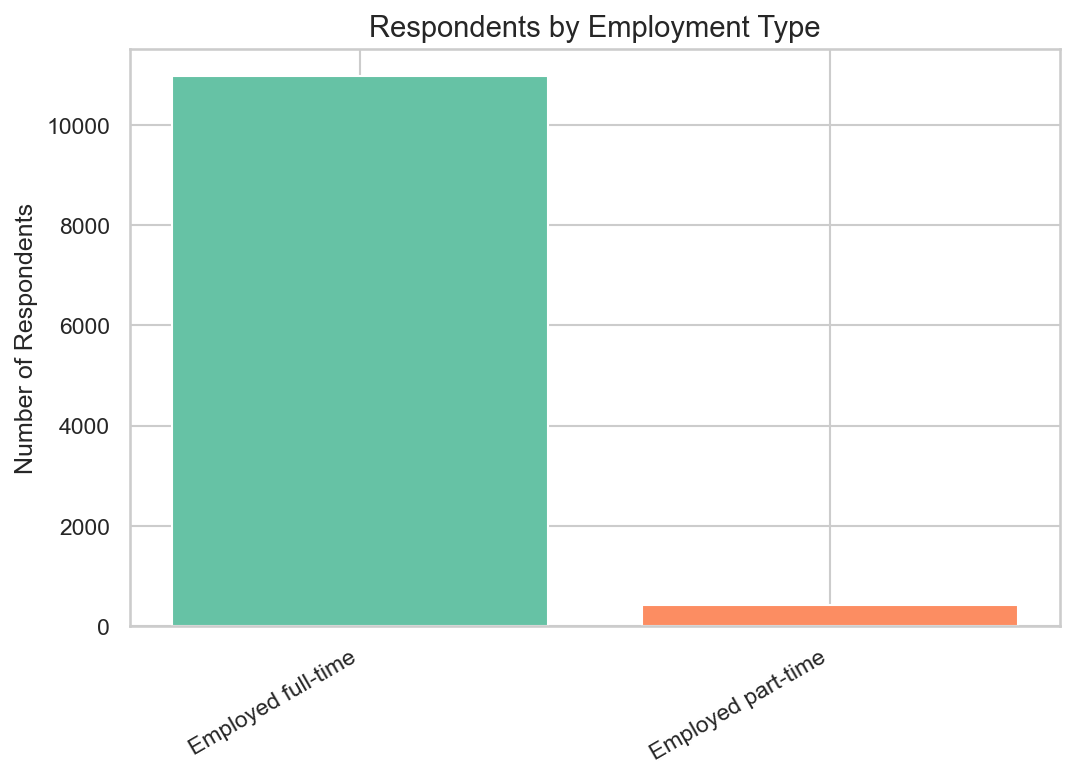

In [20]:
# ── CELL 14: CHART 11 — Stacked bar: Employment type breakdown ───────────────
df_emp = query("""
    SELECT Employment, COUNT(*) AS Count
    FROM   master
    WHERE  Employment IS NOT NULL
    GROUP  BY Employment
    ORDER  BY Count DESC
""")

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("Set2", len(df_emp))
ax.bar(df_emp["Employment"], df_emp["Count"], color=colors)
ax.set_title("Respondents by Employment Type", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of Respondents")
plt.xticks(rotation=30, ha="right")
save_fig("11_employment_type.png")

In [21]:
# ── CELL 15: Close the database connection ────────────────────────────────────
conn.close()
print("All charts saved to:", os.path.abspath(IMG_DIR))
print("Database connection closed.")

All charts saved to: c:\Users\Hamza\Desktop\NPower Canada\IBM Data Analyst\9 IBM Data Analyst Capstone Project\IBM_Capstone_Project\images
Database connection closed.
